In [111]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

import os
from langchain_huggingface import HuggingFaceEmbeddings
import faiss
from langchain.agents.agent_toolkits import SQLDatabaseToolkit
from langchain_community.utilities import SQLDatabase
from langchain.agents import initialize_agent, AgentType

load_dotenv()

True

In [7]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "ConversationalAIBot"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["HUGGINGFACE_API_KEY"] = os.getenv("HUGGINGFACE_API_KEY")

Embedding Model

In [17]:
#Vector Embeddings (Embedding Model Output features : 384)

from langchain.embeddings import HuggingFaceEmbeddings
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2", model_kwargs = {"device" : "cpu"})
embedding_model

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
), model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={'device': 'cpu'}, encode_kwargs={}, multi_process=False, show_progress=False)

LLM Model

In [18]:
model = ChatGroq(temperature=0, model_name="deepseek-r1-distill-llama-70b", streaming=True)

In [19]:
#Check 

print(model.invoke("Hi Google").content)

<think>

</think>

Hello! How can I assist you today? 😊


Loading Vector Database

In [20]:
#Local
from langchain_community.vectorstores import FAISS
from langchain_community.docstore import InMemoryDocstore

local_vector_db = FAISS.load_local("C:/Users/bharath.sr.lv/Desktop/ConversationalAI/Conversational_Ai/Data1/conversation_faiss_index",
                                    embeddings=embedding_model,
                                    allow_dangerous_deserialization=True)

In [21]:
vector_db = local_vector_db.as_retriever(search_kwargs={"k":2})

vector_db.invoke("I am facing internet issues and my screen is buffereing")

[Document(id='00a55f1e-6944-4b10-80fe-c60cccbeeb19', metadata={'intent': 'report_poor_signal_coverage'}, page_content='"Instruction: \n    i got to report poor internet signal covedrage i need help\n    Intent: report_poor_signal_coverage\n    Category: COMPLAINTS\n    Tags: BCLQZ\n    Response: We recognize the importance of reliable signal coverage for effective communication. Please follow the steps below to report any issues you are experiencing with poor signal coverage:\r\n\r\n1. Visit our website at {{WEBSITE_URL}}.\r\n2. Navigate to the {{SUPPORT_SECTION}} section.\r\n3. Select the option labeled {{REPORT_POOR_SIGNAL_COVERAGE_OPTION}}.\r\n4. Fill in the required details, including your location and issue description.\r\n5. Submit the form to notify our team.\r\n\r\nOur team will assess your submission and take appropriate measures to enhance network coverage in your vicinity.'),
 Document(id='3730584b-f5d3-42ce-91de-03dbf2c36c02', metadata={'intent': 'report_poor_signal_coverag

#### Lang Graph Workflow

For Intent classification Using Pydantic output Parser

In [68]:
from typing import TypedDict, List, Optional

class AgentState(TypedDict):
    messages: List
    customer_id: Optional[str]
    intent: Optional[str]
    user_query: Optional[str]
    customer_data: Optional[str]
    retrieved_context: Optional[str]

In [109]:
#Using pydantic

from pydantic import BaseModel, Field
from langchain.output_parsers import PydanticOutputParser
class Intent_Classifier(BaseModel):
    """Intent Classifier"""
    customer_id: str = Field(description="The customer ID in the format CUSTXXXX")
    intent: str = Field(description="Intent of the user query")
    query: str = Field(description="User query")
    Reasoning: str = Field(description='Reasoning behind topic selection')


parser = PydanticOutputParser(pydantic_object=Intent_Classifier)

In [70]:
print(parser.get_format_instructions())

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"description": "Intent Classifier", "properties": {"customer_id": {"description": "The customer ID in the format CUSTXXXX", "title": "Customer Id", "type": "string"}, "intent": {"description": "Intent of the user query", "title": "Intent", "type": "string"}, "query": {"description": "User query", "title": "Query", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["customer_id", "intent", "query", "Reasoning"]}
```


Creating State Graph using Langflow

In [71]:
import operator
from typing import List
from langchain.prompts import PromptTemplate
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

In [72]:
llm = ChatGroq(temperature=0, model_name="deepseek-r1-distill-llama-70b", streaming=True)

In [ ]:
# #Defining State
# class AgentState(TypedDict):
#     messages: Annotated[Sequence[BaseMessage], operator.add]

Supervisor Node

In [73]:
from langchain.prompts import PromptTemplate

def supervisor_node(state: AgentState) -> AgentState:
    print("--------------------------Supervisor---------------------------")
    user_question = state["messages"][-1].content

    template  = """
        You are a telecom assistant that classifies the user's intent into one of the following:
    - Plan: If the user is asking about mobile, broadband, or 5G plans.
    - Complaint: If the user is reporting issues like network outage, slow internet, or billing problems.
    - Other: For greetings, general questions, or unrelated topics.

    Your job is to classify the intent and explain your reasoning.

    User Query: {question}

    {format_instructions}
    """
    prompt = PromptTemplate(
        input_variable = ["question"],
        partial_variables={"format_instructions": parser.get_format_instructions()},
        template = template
    )

    chain = prompt | llm | parser

    response  = chain.invoke({"question":user_question})

    print("Parsed Response: ", response)

    # return {
    #     "messages": [
    #         AIMessage(content=response.intent),
    #         HumanMessage(content=response.Reasoning)
    #     ],
    #     "customer_id": response.customer_id,
    #     "user_query": response.query,
    #     "intent": response.intent
    # }

    return {
        "messages": state["messages"] + [
            AIMessage(content=f"Intent: {response.intent}"),
            AIMessage(content=f"Reasoning: {response.Reasoning}"),
            AIMessage(content=f"Customer ID: {response.customer_id}")
        ],
        "customer_id": response.customer_id,
        "intent": response.intent,
        "user_query": response.query
    }

In [ ]:
#check
state = {
    "messages": [
        HumanMessage(content="My Plan is not sufficient and i need more data what can I do My ID is CUST1001?")
    ]
}
supervisor_node(state)

# state = {
#     "messages": [
#         HumanMessage(content="I am facing buffering issue with my plan and there is no speed in 5G band and though I pay for 5G")
#     ]
# }
# supervisor_node(state)

--------------------------Supervisor---------------------------
Parsed Response:  customer_id='CUST1001' intent='Plan' query='My Plan is not sufficient and i need more data what can I do My ID is CUST1001?' Reasoning='The user is discussing their current plan and the need for more data, indicating they are looking to adjust their plan.'


In [ ]:
# result.get("customer_id")

'CUST1001'

Creating SQL Agent

In [195]:
from langchain_groq import ChatGroq
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_core.tools import Tool
from langchain.agents import AgentExecutor, create_openai_functions_agent
import re
from langchain.agents import initialize_agent

In [198]:
sql_llm = ChatGroq(model="gemma2-9b-it", temperature=0.2,streaming=True)

db = SQLDatabase.from_uri("sqlite:///C:/Users/bharath.sr.lv/Desktop/ConversationalAI/Conversational_Ai/Data1/telecom_customer.db")
toolkit = SQLDatabaseToolkit(db=db, llm=sql_llm)

agent_executor = initialize_agent(
    tools=toolkit.get_tools(),
    llm=sql_llm,
    agent="zero-shot-react-description",
    verbose=True
)

In [199]:
import json 
import re

def extract_json_from_string(text: str) -> dict:
    text = text.strip("` \n")
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        raise ValueError("No JSON object found in response.")
    json_str = match.group(0)
    json_str = json_str.replace("\\x93", "-").replace("'", '"')
    return json.loads(json_str)

def SQL_agent(state: dict) -> dict:

    print("------------ SQL Agent Node ------------")

    customer_id = state.get("customer_id")
    if not customer_id:
        return {
            **state,
            "messages": state["messages"] + [("assistant", "Customer ID is missing.")],
            "customer_data": None
        }

    query = f"Get customer details for ID '{customer_id}' from the 'customers' table. Respond only with the result in JSON format."

    response = agent_executor.invoke({"input": query})
    full_output = response.get("output", str(response))

    try:
        parsed_data = extract_json_from_string(full_output)
    except Exception as e:
        parsed_data = None
        full_output += f"\n\n Parsing error: {str(e)}"

    return {
        **state,
        "messages": state["messages"] + [("assistant", full_output)],
        "customer_data": parsed_data
}

In [200]:
state = {
    "customer_id": "CUST1005",
    "messages": [("user", "Tell me about my current plan")]
}

new_state = SQL_agent(state)
print(new_state["customer_data"])

------------ SQL Agent Node ------------


> Entering new AgentExecutor chain...
Thought: I need to construct a SQL query to select customer details for a specific ID from the 'customers' table. 
Action: sql_db_query_checker
Action Input: SELECT * FROM customers WHERE customer_id = 'CUST1005'
Observation: SELECT * FROM customers WHERE customer_id = 'CUST1005' 

Thought:Thought: The query looks correct. I can execute it now.
Action: sql_db_query
Action Input: SELECT * FROM customers WHERE customer_id = 'CUST1005'
Observation: Error: (sqlite3.OperationalError) no such column: customer_id
[SQL: SELECT * FROM customers WHERE customer_id = 'CUST1005']
(Background on this error at: https://sqlalche.me/e/20/e3q8)
Thought:Thought: The error message indicates that the 'customer_id' column doesn't exist in the 'customers' table. I need to check the table schema to see the available columns.
Action: sql_db_schema
Action Input: customers
Observation: 
CREATE TABLE customers (
	"Customer ID" TEXT, 

RAG Agent

In [176]:
from langchain_core.tools import tool

def RAG_agent(state:AgentState) -> AgentState:
    query = state.get("user_query")
    """
    Combines the user query and SQL customer context to retrieve the most relevant information 
    from the vector DB (e.g. troubleshooting guides, plan info, etc.).

    Parameters:
    - query (str): The user's original question (e.g., "Why is my network slow?")
    - customer_context (str): The context retrieved from SQL agent (e.g., customer location, plan, device)

    Returns:
    - str: Top-k retrieved document contents concatenated.
    """
    retriever = local_vector_db.as_retriever(search_kwargs={"k":2})
    documents = retriever.invoke(query)

    context = "\n\n".join([doc.page_content for doc in documents])
    return {
    "messages": state["messages"] + [AIMessage(content=context)],
    "retrieved_context": context
}  

Plan Explainer & Marketer

In [215]:
from langchain_core.output_parsers import StrOutputParser

plan_explainer_parser = StrOutputParser()

In [228]:
def Plan_Explainer(state: AgentState) -> AgentState:
    print("--------------------------Plan Explainer---------------------------")

    query = state.get("user_query")
    intent = state.get("intent")
    customer_id = state.get("customer_id")
    customer_data = state.get("customer_data")
    plan_info = """
    1. Basic Plan: $20–$30/month, includes 5 GB high-speed data, unlimited calls, 1000 SMS/month, 128 Kbps after limit, no roaming.
    2. Unlimited Plan: $30–$50/month, truly unlimited data (FUP after 50 GB), unlimited calls/SMS, 1 Mbps post-FUP, 5G, cloud storage, hotspot.
    3. Family Plan: $60–$100/month for 3–5 lines, shared 50–100 GB data, unlimited calls/SMS, 256 Kbps post-limit, includes parental controls.
    4. Premium Plan: $40–$60/month, unlimited high-speed (throttled after 100 GB), includes international calls, priority support, streaming.
    5. Data-Only Plan: $15–$25/month, 10–20 GB high-speed data, no calls/SMS, 512 Kbps post-limit, supports tethering and hotspots.
    """
    format_instructions = """
    Return a JSON object with the following keys:
    - plan_details
    - query_response
    - cross_sell_recommendation
    - reasoning
    """

    template = """
    You are a telecom marketing assistant. Your job is to address the user by name and explain the user's current plan clearly and offer an upgrade suggestion **only if appropriate**.

    You must perform the following tasks:
    1. Summarize the customer's **current plan** in simple, friendly language.
    2. Explain how the plan features address the user's query.
    3. If the plan is **outdated**, **limited**, or **not optimal** based on their usage, suggest an **upgrade** (cross-sell) with a compelling reason.
    4. Be helpful, not pushy. Do not upsell if the user is already on a top-tier plan.

    Use the information below:

    ---
    **Available Data**:
    {plan_info}

    **Customer Data**:
    {customer_data}

    **User Query**:
    {query}

    **Intent**: {intent}  
    **Customer ID**: {customer_id}

    Given a customer's current data, current and query, respond in the following JSON format:

    {{
    "plan_details": "...",
    "query_response": "...",
    "cross_sell_recommendation": "...",
    "reasoning": "..."
    }}
    """

    prompt = PromptTemplate(
        input_variables=["customer_data", "query", "intent", "customer_id", "plan_info"],
        template=template
    )

    chain = prompt | llm | plan_explainer_parser

    response = chain.invoke({
        "query": query,
        "customer_data": customer_data,
        "intent": intent,
        "customer_id": customer_id,
        "plan_info": plan_info
    })

    print("Plan Explainer Response:", response)

    json_match = re.search(r"\{[\s\S]*\}", response)
    if json_match:
        json_part = json_match.group(0)
        try:
            response = json.loads(json_part)
        except json.JSONDecodeError as e:
            print("JSON parsing error:", e)
            return state
    else:
        print("No JSON object found in response.")
        return state

    return {
            "messages": state["messages"] + [AIMessage(content=str(response))],
            "plan_details": response["plan_details"],
            "query_response": response["query_response"],
            "cross_sell_recommendation": response["cross_sell_recommendation"],
            "reasoning": response["reasoning"]
        }


In [229]:
#check

sample_state = {
    "user_query": "I'm getting a lot of overage charges lately. Is there a better plan for heavy data users?",
    "intent": "Plan Upgrade Inquiry",
    "customer_id": "CUST1234",
    "customer_data": {
        "name": "Ravi Kumar",
        "current_plan": "Basic Plan",
        "monthly_usage_gb": 12,
        "calls_per_month": 800,
        "sms_per_month": 500,
        "monthly_bill_usd": 28
    },
    "messages": []
}
Plan_Explainer(sample_state)

--------------------------Plan Explainer---------------------------
Plan Explainer Response: <think>
Okay, so I need to help Ravi Kumar with his telecom plan. He's on the Basic Plan right now, which costs him $28 a month. Let me look at the details of his current plan. It includes 5 GB of high-speed data, unlimited calls, 1000 SMS per month, and after he uses up the 5 GB, the speed drops to 128 Kbps. He doesn't get any roaming either.

Ravi's usage is 12 GB of data each month, which is way more than the 5 GB his plan offers. That explains why he's getting overage charges. He's also making 800 calls and sending 500 SMS, which is within the limits of his current plan since it offers unlimited calls and 1000 SMS. So, his main issue is the data overage.

He's asking if there's a better plan for heavy data users. Looking at the available plans, the Unlimited Plan seems like a good fit. It offers truly unlimited data with a fair usage policy after 50 GB, which is way more than Ravi's 12 GB. 

{'messages': [AIMessage(content='{\'plan_details\': "Hi Ravi, you\'re currently on the Basic Plan which costs $28/month. It includes 5 GB of high-speed data, unlimited calls, 1000 SMS/month, and data speeds drop to 128 Kbps after the limit.", \'query_response\': "I understand you\'re experiencing overage charges due to your high data usage of 12 GB/month. Your current plan\'s 5 GB limit is why you\'re seeing these charges.", \'cross_sell_recommendation\': \'I recommend upgrading to the Unlimited Plan. It offers unlimited data with a 50 GB fair usage policy, better post-limit speeds of 1 Mbps, and includes 5G, cloud storage, and hotspot. This should eliminate overage charges and enhance your mobile experience.\', \'reasoning\': "Ravi\'s data usage exceeds his current plan\'s limit, causing overage charges. The Unlimited Plan\'s higher data allowance and better features make it a suitable upgrade to meet his needs without being pushy."}', additional_kwargs={}, response_metadata={})],
 'p

In [217]:
def summarizer_agent(state: AgentState) -> AgentState:
    print("--------------------------Summarizer Node---------------------------")

    intent = state.get("intent", "").lower()
    customer_id = state.get("customer_id", "Unknown")
    query = state.get("user_query", "N/A")

    base_inputs = {
        "intent": intent,
        "customer_id": customer_id,
        "query": query
    }

    if intent == "plan":
        plan_details = state.get("plan_details", "")
        query_response = state.get("query_response", "")
        upgrade_suggestion = state.get("cross_sell_recommendation", "")

        template = """
        You are a telecom assistant. Summarize the following plan conversation:

        - Greet the customer.
        - Mention their plan briefly.
        - Respond to their query.
        - Suggest an upgrade only if applicable.

        ---
        Customer ID: {customer_id}
        User Query: {query}
        Plan Details: {plan_details}
        Response: {query_response}
        Upgrade Suggestion: {upgrade_suggestion}
        """

        inputs = {
            **base_inputs,
            "plan_details": plan_details,
            "query_response": query_response,
            "upgrade_suggestion": upgrade_suggestion
        }

    elif intent == "complaint":
        grievance_context = state.get("retrieved_context", "")
        complaint_response = state.get("complaint_resolution", "")

        template = """
        You are a telecom assistant helping a customer with a complaint.

        - Acknowledge the customer's concern.
        - Explain any available context or resolution.
        - Be empathetic and professional.

        ---
        Customer ID: {customer_id}
        User Query: {query}
        Complaint Context: {grievance_context}
        Complaint Resolution: {complaint_response}
        """

        inputs = {
            **base_inputs,
            "grievance_context": grievance_context,
            "complaint_response": complaint_response
        }

    else:
        template = """
        Summarize the user query and acknowledge the message in a general way.

        ---
        Customer ID: {customer_id}
        User Query: {query}
        """

        inputs = base_inputs

    prompt = PromptTemplate.from_template(template)
    chain = prompt | llm
    summary = chain.invoke(inputs)

    return {
        "messages": state["messages"] + [AIMessage(content=summary)],
        "summary": summary
    }

Router

In [218]:
def Router(state: AgentState) -> AgentState:
    """
    Determines the next node to route to based on the user's intent.

    Inputs:
        - Should include key 'intent'

    Returns:
        - str: The name of the next node
    """
    print("--------------------------Router Node---------------------------")

    intent = state.get("intent", "").lower()

    if intent == "plan":
        return "Plan_Explainer"
    elif intent == "complaint":
        return "RAG_agent"
    else:
        return "fallback" 

Implementing Langgraph

In [236]:
app_workflow = StateGraph(AgentState)

app_workflow.add_node("supervisor_agent", supervisor_node)
app_workflow.add_node("SQL_agent", SQL_agent)
app_workflow.add_node("RAG_agent", RAG_agent)
app_workflow.add_node("Plan_Explainer", Plan_Explainer)
# app_workflow.add_node("Summarizer_LLM", summarizer_agent)

app_workflow.add_edge(START, "supervisor_agent")
app_workflow.add_edge("supervisor_agent", "SQL_agent")
app_workflow.add_conditional_edges(
    "SQL_agent",
    Router,
    {
        "Plan_Explainer" : "Plan_Explainer",
        "RAG_agent" : "RAG_agent"
    }
)
# app_workflow.add_edge("Plan_Explainer", "Summarizer_LLM")
app_workflow.add_edge("Plan_Explainer", END)
app_workflow.add_edge("supervisor_agent", END)

In [246]:
app = app_workflow.compile()

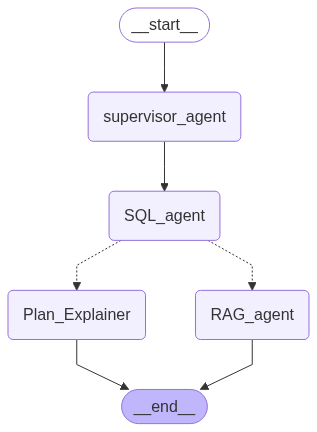

In [247]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))

In [257]:
sample_state = {
    "messages": [
        HumanMessage(content="Hi my customer id is CUST1017.I am not having sufficient data for my entire family and the speed is also not that great, what are some of the other options from the plan that i use?")
    ]
}

In [258]:
flow_response = app.invoke(sample_state)

--------------------------Supervisor---------------------------
Parsed Response:  customer_id='CUST1017' intent='Plan' query='Hi my customer id is CUST1017. I am not having sufficient data for my entire family and the speed is also not that great, what are some of the other options from the plan that i use?' Reasoning='The user is inquiring about other plan options due to insufficient data and slow speed, indicating they are looking to change their current plan.'
------------ SQL Agent Node ------------


> Entering new AgentExecutor chain...
Thought: I need to construct a SQL query to select customer details for a specific ID from the 'customers' table. 
Action: sql_db_query_checker
Action Input: SELECT * FROM customers WHERE customer_id = 'CUST1017'
Observation: SELECT * FROM customers WHERE customer_id = 'CUST1017' 

Thought:Thought: The query looks correct. I can execute it now.
Action: sql_db_query
Action Input: SELECT * FROM customers WHERE customer_id = 'CUST1017'
Observation: E

In [256]:
for output in app.stream(sample_state):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("________________________________________________________________________")
        print(value)
        print("\n")

--------------------------Supervisor---------------------------
Parsed Response:  customer_id='CUST1007' intent='Plan' query='Hi my customer id is CUST1007. I would like to check for alternative options from my currently subscribed plan to have more calls and data. I am not having extra data' Reasoning='The user is inquiring about alternative plans to get more calls and data, which falls under the Plan intent.'
Output from supervisor_agent Node
________________________________________________________________________
{'messages': [HumanMessage(content='Hi my customer id is CUST1007. I would like to check for alternative options from my currently subscribed plan to have more calls and data. I am not having extra data', additional_kwargs={}, response_metadata={}), AIMessage(content='Intent: Plan', additional_kwargs={}, response_metadata={}), AIMessage(content='Reasoning: The user is inquiring about alternative plans to get more calls and data, which falls under the Plan intent.', addition